# 05 -- Message passing (graph neural nets)

**Modern potentials are geometry-aware GNNs.**

Notebook 04 showed that symmetry functions work -- but they are hand-designed. The network cannot adjust the representation to fit the data.

The key insight of graph neural networks for molecules is:

> Represent a molecule as a graph (atoms = nodes, neighbour pairs = edges), then let the network iteratively update each atom's representation by aggregating messages from its neighbours.

After $T$ rounds of message passing, each atom's embedding encodes information about its $T$-hop neighbourhood. For $T=3$ or so, that is enough to capture almost any local chemistry.

This is what SchNet, DimeNet, NequIP, MACE and all modern foundation models do. In this notebook we build the core from scratch:
1. Represent atoms as a graph with edge features (distances).
2. Implement one round of message passing.
3. Stack rounds, read out the energy, train, and run MD.

> **Prerequisites:** Notebooks 01-04.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from afs.md import (
    lj_energy, lj_forces, triangular_lattice,
    disk_cluster, thermal_velocities, run_md,
)

torch.manual_seed(0)
np.random.seed(0)

## 1. A molecule is a graph

We build an **edge list**: for each pair of atoms within the cutoff radius $r_c$, we add a directed edge in both directions. Each edge carries the displacement vector and distance.

This representation is **sparse** (only nearby pairs matter, cost $O(N)$ not $O(N^2)$), **permutation-equivariant** (the graph is defined by physical proximity, not atom ordering), and **translation-invariant** (we store *relative* displacements).

9 atoms, 64 directed edges (r_cut=2.5)


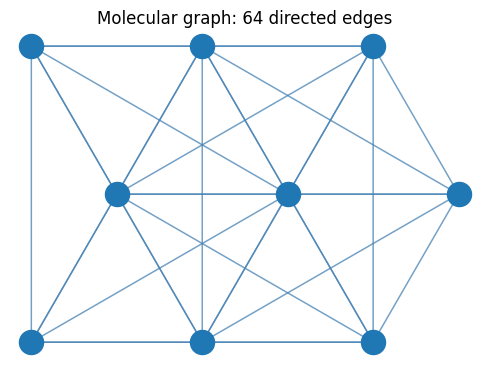

In [2]:
def build_graph(pos, r_cut=3.5):
    """Neighbour-list graph. Returns (src, dst, edge_vec, edge_dist) as numpy arrays.

    Only the src/dst *indices* are used downstream for the differentiable model; the
    displacement vectors and distances are recomputed in torch inside the model so that
    gradients flow back to the atomic positions.
    """
    n = len(pos)
    src, dst, vecs, dists = [], [], [], []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            diff = pos[j] - pos[i]
            r = np.linalg.norm(diff)
            if r < r_cut:
                src.append(i); dst.append(j)
                vecs.append(diff); dists.append(r)
    return (np.array(src), np.array(dst), np.array(vecs), np.array(dists))

pos = triangular_lattice(3, 3)
src, dst, vecs, dists = build_graph(pos, r_cut=2.5)
print(f'9 atoms, {len(src)} directed edges (r_cut=2.5)')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pos[:, 0], pos[:, 1], s=300, zorder=5)
for s, d in zip(src, dst):
    ax.annotate('', xy=pos[d], xytext=pos[s],
                arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.5))
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Molecular graph: {len(src)} directed edges')
plt.tight_layout(); plt.show()

## 2. Edge features: expanding distances in a radial basis

A scalar distance is too little information per edge. We expand each distance into a vector using a **radial basis function (RBF)** expansion: a set of Gaussian bumps spread across $[0, r_c]$. This is the GNN analogue of the radial symmetry functions from Notebook 04, but the edge features feed into *learned* message functions.

> We define the RBF twice: a NumPy version for plotting, and a torch method inside the model (Section 4) that keeps the autograd graph so forces can be differentiated through it.

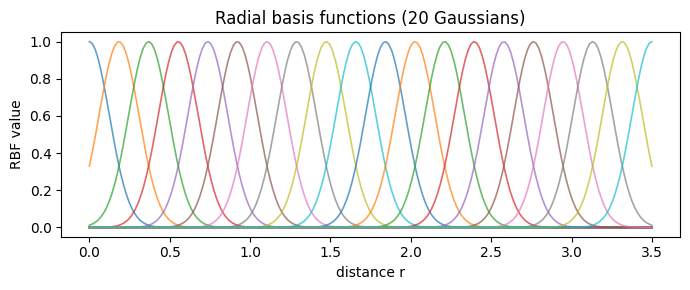

In [3]:
def rbf_expansion(dists, n_rbf=20, r_cut=3.5):
    """Expand scalar distances into (E, n_rbf) RBF features (numpy, for plotting)."""
    centers = np.linspace(0, r_cut, n_rbf)
    width = (r_cut / n_rbf) ** 2
    x = dists[:, None]
    return np.exp(-((x - centers) ** 2) / width)

r_plot = np.linspace(0, 3.5, 200)
rbf_plot = rbf_expansion(r_plot, n_rbf=20)
plt.figure(figsize=(7, 3))
for col in rbf_plot.T:
    plt.plot(r_plot, col, lw=1.2, alpha=0.7)
plt.xlabel('distance r'); plt.ylabel('RBF value')
plt.title('Radial basis functions (20 Gaussians)')
plt.tight_layout(); plt.show()

## 3. One round of message passing

The core operation of a GNN is a **message-passing step**:

```
for each atom i:
    messages = [message_net(h[i], h[j], e_ij) for j in neighbours(i)]
    h[i]_new = update_net(h[i], sum(messages))
```

The messages are **summed** over neighbours (permutation invariance), and `update_net` combines the old embedding with the aggregated messages. After $T$ rounds, each atom's embedding encodes its $T$-hop environment.

In [4]:
class MessagePassingLayer(nn.Module):
    """One round of message passing with a residual update."""
    def __init__(self, node_dim, edge_dim):
        super().__init__()
        self.message_net = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, node_dim), nn.SiLU(),
            nn.Linear(node_dim, node_dim),
        )
        self.update_net = nn.Sequential(
            nn.Linear(2 * node_dim, node_dim), nn.SiLU(),
            nn.Linear(node_dim, node_dim),
        )

    def forward(self, h, edge_src, edge_dst, edge_feat):
        h_src = h[edge_src]                       # (E, node_dim)
        h_dst = h[edge_dst]                       # (E, node_dim)
        inp = torch.cat([h_src, h_dst, edge_feat], dim=-1)
        msgs = self.message_net(inp)              # (E, node_dim)
        agg = torch.zeros_like(h)
        agg.index_add_(0, edge_dst, msgs)         # sum incoming edges
        h_new = self.update_net(torch.cat([h, agg], dim=-1))
        return h + h_new                          # residual

# Quick shape test
D_node, D_edge = 32, 20
layer = MessagePassingLayer(D_node, D_edge)
h_test = torch.randn(9, D_node)
edge_feat_t = torch.tensor(rbf_expansion(dists), dtype=torch.float32)
src_t = torch.tensor(src, dtype=torch.long)
dst_t = torch.tensor(dst, dtype=torch.long)
h_out = layer(h_test, src_t, dst_t, edge_feat_t)
print(f'Input shape:  {tuple(h_test.shape)}')
print(f'Output shape: {tuple(h_out.shape)} (updated, not resized)')

Input shape:  (9, 32)
Output shape: (9, 32) (updated, not resized)


## 4. Full GNN potential: message passing + energy readout

We stack $T$ message-passing layers, then read out the energy as a sum of per-atom scalar contributions:

$$E = \sum_{i=1}^{N} \text{readout}(\mathbf{h}_i^{(T)})$$

Summing per-atom contributions makes the potential **size-extensive**.

> **The crucial detail for forces.** The neighbour *list* (which pairs are edges) is built on detached positions, but the edge **distances** are recomputed in torch directly from `pos_t`, and expanded with a torch RBF. This keeps `pos_t` in the autograd graph, so $\mathbf{F} = -\partial E/\partial \mathbf{r}$ is well defined. (If you build the distances in NumPy, the energy does not depend on the positions and the forces come back as `None`.)

In [5]:
class GNNPotential(nn.Module):
    """GNN energy model: T rounds of message passing + per-atom readout.

    forward(pos_t) takes an (N, d) torch tensor and returns a scalar energy that is
    differentiable w.r.t. pos_t.
    """
    def __init__(self, node_dim=32, n_rbf=20, r_cut=3.5, n_layers=3):
        super().__init__()
        self.node_dim = node_dim
        self.n_rbf = n_rbf
        self.r_cut = r_cut
        self.atom_embed = nn.Embedding(1, node_dim)   # one species here
        self.mp_layers = nn.ModuleList([
            MessagePassingLayer(node_dim, n_rbf) for _ in range(n_layers)
        ])
        self.readout = nn.Sequential(
            nn.Linear(node_dim, node_dim // 2), nn.SiLU(),
            nn.Linear(node_dim // 2, 1),
        )
        # RBF centers as a fixed buffer so they move with .to(device)
        self.register_buffer('centers', torch.linspace(0, r_cut, n_rbf))
        self.width = (r_cut / n_rbf) ** 2

    def _rbf_torch(self, edge_dist):
        """Differentiable RBF expansion of (E,) torch distances -> (E, n_rbf)."""
        x = edge_dist[:, None]                        # (E, 1)
        return torch.exp(-((x - self.centers) ** 2) / self.width)

    def forward(self, pos_t):
        # 1) neighbour list on detached positions (membership is a step function)
        pos_np = pos_t.detach().numpy()
        e_src, e_dst, _, _ = build_graph(pos_np, self.r_cut)
        src_t = torch.tensor(e_src, dtype=torch.long)
        dst_t = torch.tensor(e_dst, dtype=torch.long)
        N = pos_t.shape[0]

        # 2) recompute edge distances IN TORCH so energy depends on positions
        edge_vec = pos_t[dst_t] - pos_t[src_t]                     # (E, d), grad kept
        edge_dist = torch.sqrt((edge_vec ** 2).sum(dim=1) + 1e-12) # (E,)
        edge_f = self._rbf_torch(edge_dist)                        # (E, n_rbf)

        # 3) message passing + readout
        h = self.atom_embed(torch.zeros(N, dtype=torch.long))
        for layer in self.mp_layers:
            h = layer(h, src_t, dst_t, edge_f)
        atom_energies = self.readout(h).squeeze(-1)                # (N,)
        return atom_energies.sum()

gnn = GNNPotential(node_dim=32, n_rbf=20, r_cut=3.5, n_layers=3)
print(f'GNN parameters: {sum(p.numel() for p in gnn.parameters()):,}')

# Sanity: the energy really does depend on positions (gradient is non-zero / not None)
p = torch.tensor(triangular_lattice(3, 3), dtype=torch.float32, requires_grad=True)
E = gnn(p); E.backward()
print('grad is not None:', p.grad is not None)
print('grad has non-zero entries:', bool((p.grad.abs() > 0).any()))

GNN parameters: 21,313
grad is not None: True
grad has non-zero entries: True


## 5. Train the GNN and run MD

We generate data the same way as before (perturbed LJ clusters), train with energy supervision, compute forces via autograd, and run MD.

In [6]:
def make_gnn_dataset(n_samples=800, noise=0.3):
    base = triangular_lattice(3, 3)
    rng = np.random.default_rng(7)
    configs, energies = [], []
    while len(energies) < n_samples:
        pos = base + noise * rng.standard_normal(base.shape)
        E = lj_energy(pos)
        if abs(E) < 50:
            configs.append(pos.copy()); energies.append(E)
    return configs, np.array(energies)

print('Generating GNN dataset...')
configs, energies = make_gnn_dataset()
print(f'{len(configs)} configs')

Generating GNN dataset...


800 configs


Training GNN (this may take ~2 minutes on CPU)...


epoch  50  train MSE=11.8931  val MSE=34.6658


epoch 100  train MSE=3.2140  val MSE=3.0897


epoch 150  train MSE=1.9910  val MSE=2.8754


epoch 200  train MSE=1.4817  val MSE=1.7306


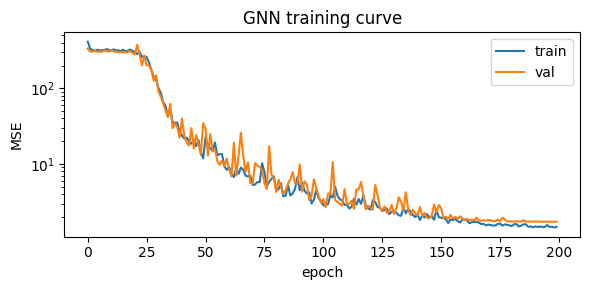

In [7]:
n_val = 150
n_train = len(configs) - n_val
train_configs, train_E = configs[:n_train], energies[:n_train]
val_configs, val_E = configs[n_train:], energies[n_train:]

opt = torch.optim.Adam(gnn.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200)

train_losses, val_losses = [], []
print('Training GNN (this may take ~2 minutes on CPU)...')
for epoch in range(200):
    gnn.train()
    perm = np.random.permutation(n_train)
    epoch_loss = 0.0
    for b_start in range(0, n_train, 32):
        opt.zero_grad()
        batch_loss = 0.0
        batch_idx = perm[b_start:b_start + 32]
        for idx in batch_idx:
            pos_t = torch.tensor(train_configs[idx], dtype=torch.float32)
            batch_loss = batch_loss + (gnn(pos_t) - train_E[idx]) ** 2
        batch_loss = batch_loss / len(batch_idx)
        batch_loss.backward()
        opt.step()
        epoch_loss += batch_loss.item()
    train_losses.append(epoch_loss / (n_train / 32))
    gnn.eval()
    with torch.no_grad():
        vl = sum((gnn(torch.tensor(c, dtype=torch.float32)).item() - e) ** 2
                 for c, e in zip(val_configs, val_E)) / n_val
    val_losses.append(vl); sched.step()
    if (epoch + 1) % 50 == 0:
        print(f'epoch {epoch+1:3d}  train MSE={train_losses[-1]:.4f}  val MSE={val_losses[-1]:.4f}')

plt.figure(figsize=(6, 3))
plt.semilogy(train_losses, label='train')
plt.semilogy(val_losses, label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.title('GNN training curve')
plt.legend(); plt.tight_layout(); plt.show()

GNN force-gradient check: max err = 0.00241
autograd == numerical: True
Running GNN-MD...


GNN-MD energy drift: 0.001%


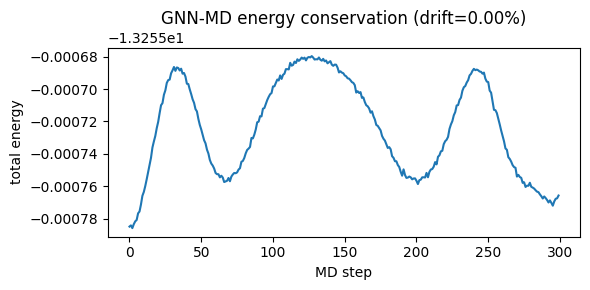

In [8]:
def gnn_forces(pos_np):
    pos_t = torch.tensor(pos_np, dtype=torch.float32, requires_grad=True)
    E = gnn(pos_t)
    E.backward()
    return -pos_t.grad.numpy()

def gnn_energy(pos_np):
    with torch.no_grad():
        return gnn(torch.tensor(pos_np, dtype=torch.float32)).item()

# Force-gradient check (now runs -- forces are no longer None)
pos_test = triangular_lattice(3, 3) + 0.05 * np.random.randn(9, 2)
F_analytic = gnn_forces(pos_test)
h = 1e-3
F_numerical = np.zeros_like(pos_test)
for i in range(pos_test.shape[0]):
    for k in range(pos_test.shape[1]):
        pp, pm = pos_test.copy(), pos_test.copy()
        pp[i, k] += h; pm[i, k] -= h
        F_numerical[i, k] = -(gnn_energy(pp) - gnn_energy(pm)) / (2 * h)
print(f'GNN force-gradient check: max err = {np.max(np.abs(F_analytic - F_numerical)):.5f}')
print(f'autograd == numerical: {np.allclose(F_analytic, F_numerical, atol=1e-2)}')

print('Running GNN-MD...')
start_pos = triangular_lattice(3, 3)
start_vel = thermal_velocities(9, d=2, temp=0.1, seed=3)
pos = start_pos.copy(); vel = start_vel.copy()
forces = gnn_forces(pos)
tot_E, dt, steps = [], 0.003, 300
for _ in range(steps):
    v_half = vel + 0.5 * forces * dt
    pos = pos + v_half * dt
    forces = gnn_forces(pos)
    vel = v_half + 0.5 * forces * dt
    tot_E.append(0.5 * np.sum(vel ** 2) + gnn_energy(pos))

drift = (max(tot_E) - min(tot_E)) / abs(np.mean(tot_E))
print(f'GNN-MD energy drift: {drift:.3%}')
plt.figure(figsize=(6, 3))
plt.plot(tot_E)
plt.xlabel('MD step'); plt.ylabel('total energy')
plt.title(f'GNN-MD energy conservation (drift={drift:.2%})')
plt.tight_layout(); plt.show()

## 6. What you built and what is next

You implemented the core of SchNet, one of the foundational GNN potentials, in about 80 lines of PyTorch. Scaled up with more layers and width, **equivariant** message passing (features that transform as tensors under rotation), multi-element embeddings, and training on millions of DFT configurations, this becomes MACE-MP -- a foundation model that simulates almost any material zero-shot. That is Notebook 06.

**What we simplified:**
- Invariant (distance-only) message passing. NequIP and MACE use **equivariant** message   passing, which is more data-efficient.
- No periodic boundary conditions.
- Energy-only training; including forces in the loss is standard and accelerates learning.

### Exercises

1. **Force loss.** Add forces to the training loss (autograd the energy during training).    How does the MD energy drift change?

2. **Deeper network.** Increase `n_layers` from 3 to 5. Does accuracy improve? Does training    time increase proportionally?

3. **Cutoff sensitivity.** Train with `r_cut=2.0` and `r_cut=5.0`. What is the trade-off?    (Hint: think about what information each atom receives.)